# ForceSMIP Challenge Analysis - Refactored

This notebook demonstrates the ForceSMIP analysis using the new encapsulated modules.

## 1. Setup and Imports

In [1]:
import sys
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

# Add src to path
sys.path.append(os.path.join(os.getcwd(), "ForceSMIP"))

# Import our modules
from data_loader import ForceSMIPDataLoader, yearly_average, compute_yearly_average_dict
from preprocessing import (
    merge_training_data, reshape_training_data, 
    apply_notnan_filter_complete
)
from algorithms import WeightedRidgeRegression, ridge_regression, LowRankSolver
from evaluation import ForceSMIPEvaluator, compute_trends_from_data, compute_statistics
from visualization import ForceSMIPVisualizer
from forcesmip_pipeline import ForceSMIPPipeline

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("Modules loaded successfully!")

Modules loaded successfully!


## 2. Quick Start - Complete Pipeline

In [2]:
# Initialize pipeline
base_path = '/net/krypton/climdyn_nobackup/FTP'
variable = 'tas'  # Precipitation

pipeline = ForceSMIPPipeline(base_path, variable=variable)
print(f"Pipeline initialized for variable: {variable}")

Pipeline initialized for variable: tas


In [3]:
# # Run complete analysis with default parameters
# summary = pipeline.run_complete_analysis(
#     lambda_reg=2500.0,     # Ridge regression regularization
#     rank=10,               # Low-rank approximation rank
#     apply_smoothing=False  # Whether to apply temporal smoothing
# )

# print("\n=== Analysis Complete! ===")

In [4]:
# # Display performance summary
# print("\n=== Performance Summary ===")
# for method, metrics in summary.items():
#     print(f"\n{method}:")
#     print(f"  Mean NRMSE: {metrics['mean_nrmse']:.4f}")
#     print(f"  Mean Pattern Correlation: {metrics['mean_pattern_corr']:.4f}")
#     print(f"  Worst NRMSE: {metrics['worst_nrmse']:.4f}")

## 3. Step-by-Step Analysis (Manual Pipeline)

### 3.1 Data Loading

In [5]:
# Initialize data loader
data_loader = ForceSMIPDataLoader(base_path)

# Load training data
print("Loading training data...")
dic_data, dic_forced_response, longitude, latitude = data_loader.load_training_data(variable)

print(f"Training data loaded:")
print(f"  Number of models: {len(dic_data)}")
print(f"  Model names: {list(dic_data.keys())}")
print(f"  Grid shape: {latitude.shape[0]} x {longitude.shape[0]}")
print(f"  Time steps: {list(dic_data.values())[0].shape[1]}")

Loading training data...
Processing 1/5: CESM2
  Processing 1/50: tas_mon_CESM2_historical_ssp370_r1251.013i1p1f1.188001-210012.nc
  Processing 2/50: tas_mon_CESM2_historical_ssp370_r1011.001i1p1f1.188001-210012.nc
  Processing 3/50: tas_mon_CESM2_historical_ssp370_r1251.015i1p1f1.188001-210012.nc
  Processing 4/50: tas_mon_CESM2_historical_ssp370_r1031.002i1p1f1.188001-210012.nc
  Processing 5/50: tas_mon_CESM2_historical_ssp370_r1251.014i1p1f1.188001-210012.nc
  Processing 6/50: tas_mon_CESM2_historical_ssp370_r1051.003i1p1f1.188001-210012.nc
  Processing 7/50: tas_mon_CESM2_historical_ssp370_r1251.016i1p1f1.188001-210012.nc
  Processing 8/50: tas_mon_CESM2_historical_ssp370_r1071.004i1p1f1.188001-210012.nc
  Processing 9/50: tas_mon_CESM2_historical_ssp370_r1251.017i1p1f1.188001-210012.nc
  Processing 10/50: tas_mon_CESM2_historical_ssp370_r1091.005i1p1f1.188001-210012.nc
  Processing 11/50: tas_mon_CESM2_historical_ssp370_r1251.018i1p1f1.188001-210012.nc
  Processing 12/50: tas_mon

In [6]:
# Load test data
test_models = ['B', 'D', 'E', 'G', 'J']
print("\nLoading test data...")
data_test = data_loader.load_test_data(variable, test_models)
data_ground_truth = data_loader.load_ground_truth(variable, test_models)
data_estimates = data_loader.load_estimates(variable, test_models)

print(f"Test data shape: {data_test.shape}")
print(f"Ground truth shape: {data_ground_truth.shape}")
print(f"Estimates shape: {data_estimates.shape}")


Loading test data...
Loading test data for G at index 3
Loading test data for D at index 1
Loading test data for J at index 4
Loading test data for E at index 2
Loading test data for B at index 0
Loading ground truth for B at index 0
Loading ground truth for D at index 1
Loading ground truth for E at index 2
Loading ground truth for G at index 3
Loading ground truth for J at index 4
Centering data for method 8
Centering data for method 9
Centering data for method 14
Centering data for method 24
Test data shape: (5, 876, 72, 144)
Ground truth shape: (5, 876, 72, 144)
Estimates shape: (30, 5, 876, 72, 144)


### 3.2 Data Preprocessing

In [7]:
# Compute yearly averages
print("Computing yearly averages...")
dic_data_yearly = compute_yearly_average_dict(dic_data)
dic_forced_response_yearly = compute_yearly_average_dict(dic_forced_response)

data_test_yearly = yearly_average(data_test)
data_ground_truth_yearly = yearly_average(data_ground_truth)

print(f"Yearly data shape (first model): {list(dic_data_yearly.values())[0].shape}")
print(f"Test yearly shape: {data_test_yearly.shape}")

Computing yearly averages...


Yearly data shape (first model): (50, 221, 72, 144)
Test yearly shape: (5, 73, 72, 144)


In [8]:
# Prepare training data for machine learning
print("Preparing training data...")

# Method 1: Merge all training data
x_train_merged, y_train_merged = merge_training_data(
    dic_data_yearly, dic_forced_response_yearly
)

# Method 2: Keep model separation
x_train_dict, y_train_dict = reshape_training_data(
    dic_data_yearly, dic_forced_response_yearly
)

print(f"Merged training data shape: X={x_train_merged.shape}, Y={y_train_merged.shape}")
print(f"Separated training data: {len(x_train_dict)} models")

Preparing training data...
Merged training data shape: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Separated training data: 5 models


### 3.3 Data Smoothing (Optional)

In [9]:
def capture_nans(x_train_dict):
    """
    Capture indices of NaN values across all training data.
    Args:
        x_train_dict (dict): Dictionary of training data tensors with keys as model names.
    Returns:
        nan_union (list): List of indices where NaN values are found across all models.
        notnan_inter (list): List of indices where no NaN values are found across all models.
    """
    
    # enumerate in the dictionary and get the union of the nans for each pair ((key, value))
    for (key, value) in x_train_dict.items():
        nan_indices = list(torch.where(torch.abs(value[0,0,:]) > 1e9)[0].numpy())
        if 'nan_union' not in locals():
            nan_union = nan_indices
        else:
            nan_union = list(set(nan_union) | set(nan_indices))

    notnan_inter = list(set(range(value.shape[2])) - set(nan_union))

    return nan_union, notnan_inter

In [10]:
nan_idx, notnan_idx =capture_nans(x_train_dict)

# Prepare test data for smoothing experiments
x_test = torch.from_numpy(data_test.reshape(
    data_test.shape[0], data_test.shape[1], -1
)).to(torch.float32)

print(f"Test data shape for smoothing: {x_test.shape}")

Test data shape for smoothing: torch.Size([5, 876, 10368])


In [11]:
# add the nans that are also included in the test data
# record nan indices as the union of nans on each map
nan_idx_test = nan_idx.copy()

for idx_r in range(x_test.shape[0]):

    nan_idx_test = list(set(nan_idx_test) | set(list(np.where(x_test[idx_r,0,:] < -1e10 )[0])))    
    # define not nan indices (useful to ease the computations)
notnan_idx_test = list(set(list(range(x_test.shape[2]))) - set(nan_idx_test))


# replace the nan index by Nans
notnan_idx = notnan_idx_test
nan_idx = nan_idx_test

In [12]:
# Apply not-NaN filter to all data
x_train_merged_filtered, y_train_merged_filtered, \
x_train_dict_filtered, y_train_dict_filtered, x_test_filtered = apply_notnan_filter_complete(
    x_train_merged, y_train_merged,
    x_train_dict, y_train_dict,
    x_test, notnan_idx
)

              APPLYING NOT-NAN FILTER TO ALL DATA
Valid indices count: 10368

1. Filtering merged training data...
   X: torch.Size([40885, 10368]) -> torch.Size([40885, 10368])
   Y: torch.Size([40885, 10368]) -> torch.Size([40885, 10368])

2. Filtering training dictionaries...
Filtering training dictionaries...
Keeping 10368 valid spatial features
CESM2: X torch.Size([50, 221, 10368]) -> torch.Size([50, 221, 10368])
CanESM5: X torch.Size([25, 221, 10368]) -> torch.Size([25, 221, 10368])
MIROC-ES2L: X torch.Size([30, 221, 10368]) -> torch.Size([30, 221, 10368])
MIROC6: X torch.Size([50, 221, 10368]) -> torch.Size([50, 221, 10368])
MPI-ESM1-2-LR: X torch.Size([30, 221, 10368]) -> torch.Size([30, 221, 10368])

3. Filtering test data...
   Test: torch.Size([5, 876, 10368]) -> torch.Size([5, 876, 10368])

=== FILTERING SUMMARY ===
Original spatial features: 10368
Filtered spatial features: 10368
Features removed: 0
Reduction: 0.0%


### 3.4 Model Training

In [88]:
# Updated cell for model training
# Train global ridge regression model
lambda_reg = 500.0
print(f"Training ridge regression with lambda={lambda_reg}...")

w_ridge = ridge_regression(x_train_merged_filtered,y_train_merged_filtered, lambda_reg, verbose=True)
print(f"Ridge weights shape: {w_ridge.shape}")

# Setup low-rank solver for efficient multiple rank solutions
print(f"\nSetting up low-rank solver...")
lr_solver = LowRankSolver()
lr_solver.fit(x_train_merged_filtered, y_train_merged_filtered, w_ridge, verbose=True)

# Get solutions for multiple ranks efficiently
ranks_to_test = [5, 10, 15, 20, 25, 30]
rank_solutions = lr_solver.get_multiple_ranks(ranks_to_test, verbose=True)

# Print explained variance for different ranks
print(f"\nExplained variance by rank:")
cumulative_var = lr_solver.cumulative_variance_ratio()
for rank in ranks_to_test:
    if rank <= len(cumulative_var):
        print(f"  Rank {rank}: {cumulative_var[rank-1]:.4f}")

# Use the primary rank solution
primary_rank = 10
w_ridge_lr = rank_solutions[primary_rank]
print(f"Primary rank-{primary_rank} weights shape: {w_ridge_lr.shape}")

Training ridge regression with lambda=500.0...
Solving ridge regression with λ=500.0
Input shape: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Reshaped: X=torch.Size([40885, 10368]), Y=torch.Size([40885, 10368])
Ridge weights computed: torch.Size([10368, 10368])
Ridge weights shape: torch.Size([10368, 10368])

Setting up low-rank solver...
Computing SVD for low-rank approximations...
SVD computed: U=torch.Size([51253, 10368]), S=torch.Size([10368]), Vt=torch.Size([10368, 10368])
Singular values range: 0.000012 to 7348.847168
Computed solutions for ranks: [5, 10, 15, 20, 25, 30]

Explained variance by rank:
  Rank 5: 0.9976
  Rank 10: 0.9996
  Rank 15: 0.9999
  Rank 20: 0.9999
  Rank 25: 0.9999
  Rank 30: 1.0000
Primary rank-10 weights shape: torch.Size([10368, 10368])


In [103]:
rank_solutions[5].shape

torch.Size([10368, 10368])

In [30]:
# Train weighted ridge regression model
print(f"\nTraining weighted ridge regression with lambda={lambda_reg}...")

# Initialize weighted ridge regression
weighted_ridge = WeightedRidgeRegression()

# Train per-model weighted regression with efficient low-rank
performance = weighted_ridge.train_per_model(
    x_train_dict_filtered, y_train_dict_filtered, lambda_reg, primary_rank, verbose=True
)

# Get multiple rank solutions for weighted models
print("Computing multiple rank solutions for weighted models...")
weighted_rank_solutions = weighted_ridge.get_rank_solutions(ranks_to_test, verbose=True)

# Compute model weights for different ranks
model_weights = {}
for rank in ranks_to_test:
    model_weights[f'rank_{rank}'] = weighted_ridge.compute_weights(
        x_train_dict_filtered, y_train_dict_filtered, use_low_rank=True, rank=rank
    )

# Also compute full model weights
model_weights['full'] = weighted_ridge.compute_weights(
    x_train_dict_filtered, y_train_dict_filtered, use_low_rank=False
)

print(f"Training complete! Performance summary:")
for model_name, perf in performance.items():
    print(f"  {model_name}: MSE_full={perf['mse_full']:.6f}, MSE_rank_{primary_rank}={perf['mse_low_rank']:.6f}")

print(f"Model weights computed for ranks: {list(model_weights.keys())}")


Training weighted ridge regression with lambda=1000.0...

Training model: CESM2
Solving ridge regression with λ=1000.0
Input shape: X=torch.Size([11050, 10368]), Y=torch.Size([11050, 10368])
Reshaped: X=torch.Size([11050, 10368]), Y=torch.Size([11050, 10368])
Ridge weights computed: torch.Size([10368, 10368])
Computing SVD for low-rank approximations...
SVD computed: U=torch.Size([21418, 10368]), S=torch.Size([10368]), Vt=torch.Size([10368, 10368])
Singular values range: 0.000005 to 2748.717529
Computing rank-10 approximation...
Rank-10 solution computed: torch.Size([10368, 10368])
  Full MSE: 0.000412
  Rank-10 MSE: 0.000416
  Explained variance: 1.0000

Training model: CanESM5
Solving ridge regression with λ=1000.0
Input shape: X=torch.Size([5525, 10368]), Y=torch.Size([5525, 10368])
Reshaped: X=torch.Size([5525, 10368]), Y=torch.Size([5525, 10368])
Ridge weights computed: torch.Size([10368, 10368])
Computing SVD for low-rank approximations...
SVD computed: U=torch.Size([15893, 1036

### 3.5 Predictions

In [89]:
# Make predictions using different methods
print("Making predictions...")

# Global models
y_pred_ridge = x_test_filtered @ w_ridge
y_pred_ridge_lr = x_test_filtered @ w_ridge_lr

# Weighted predictions
y_pred_weighted = weighted_ridge.predict_weighted(
    x_test_filtered, model_weights['full'], use_low_rank=False
)
y_pred_weighted_lr = weighted_ridge.predict_weighted(
    x_test_filtered, model_weights['rank_10'], use_low_rank=True
)


print(f"Predictions shape: {y_pred_ridge.shape}")
print("Prediction methods:")
print("  - Ridge regression")
print("  - Ridge regression + Low-rank")
print("  - Weighted ridge")
print("  - Weighted ridge + Low-rank")

Making predictions...
Predictions shape: torch.Size([5, 876, 10368])
Prediction methods:
  - Ridge regression
  - Ridge regression + Low-rank
  - Weighted ridge
  - Weighted ridge + Low-rank


### 3.6 Evaluation

In [32]:
# data_subset = data_ground_truth_yearly[:, slice(30, None), :].reshape(
#     data_ground_truth_yearly.shape[0], 
#     data_ground_truth_yearly.shape[1] - 30, 
#     -1
# )
# trends = np.zeros((data_subset.shape[0], data_subset.shape[2]), dtype=np.float32)
    
# for i in range(data_subset.shape[0]):
#     trends[i, :] = np.polyfit(np.arange(data_subset.shape[1]), data_subset[i, :, :], 1)[0]


In [90]:
# Initialize evaluator
evaluator = ForceSMIPEvaluator()

# Convert predictions to yearly averages and compute trends
def to_yearly_and_trends(pred_data, trend_years=slice(30, None)):
    """Helper function to convert monthly to yearly and compute trends."""
    pred_numpy = pred_data.cpu().numpy() if isinstance(pred_data, torch.Tensor) else pred_data
    pred_yearly = pred_numpy.reshape(pred_numpy.shape[0], pred_numpy.shape[1] // 12, 12, pred_numpy.shape[2])
    pred_yearly = pred_yearly.mean(axis=2)
    return compute_trends_from_data(pred_yearly, trend_years)

# Compute trends for all predictions
trend_years = slice(30, None)  # Last 43 years for trend computation

# reshape the data ground truth for trend computation
data_ground_truth_yearly = data_ground_truth_yearly.reshape(
    data_ground_truth_yearly.shape[0], 
    data_ground_truth_yearly.shape[1],
    -1
)

trends_ground_truth = compute_trends_from_data(data_ground_truth_yearly, trend_years)
trends_ridge = to_yearly_and_trends(y_pred_ridge, trend_years)
trends_ridge_lr = to_yearly_and_trends(y_pred_ridge_lr, trend_years)
trends_weighted = to_yearly_and_trends(y_pred_weighted, trend_years)
trends_weighted_lr = to_yearly_and_trends(y_pred_weighted_lr, trend_years)

print(f"Trends computed for {trends_ground_truth.shape[0]} test cases")
print(f"Trend groundtruth shape: {trends_ground_truth.shape}")
print(f"Trend shape: {trends_ridge.shape}")

Trends computed for 5 test cases
Trend groundtruth shape: (5, 10368)
Trend shape: (5, 10368)


In [91]:
# Evaluate all methods
predictions_dict = {
    'Ridge': trends_ridge,
    'Ridge + Low-rank': trends_ridge_lr,
    'Weighted Ridge': trends_weighted,
    'Weighted Ridge + Low-rank': trends_weighted_lr
}

comparison_results = evaluator.compare_methods(predictions_dict, trends_ground_truth[:, notnan_idx])

print("\n=== Method Comparison ===")
for method, results in comparison_results.items():
    print(f"\n{method}:")
    print(f"  Mean NRMSE: {results['mean_nrmse']:.4f}")
    print(f"  Mean Pattern Corr: {results['mean_pattern_corr']:.4f}")
    print(f"  Worst NRMSE: {results['worst_nrmse']:.4f}")
    print(f"  NRMSE Variance: {results['variance_nrmse']:.4f}")


=== Method Comparison ===

Ridge:
  Mean NRMSE: 0.2956
  Mean Pattern Corr: 0.9724
  Worst NRMSE: 0.4024
  NRMSE Variance: 0.0067

Ridge + Low-rank:
  Mean NRMSE: 0.3033
  Mean Pattern Corr: 0.9701
  Worst NRMSE: 0.4046
  NRMSE Variance: 0.0068

Weighted Ridge:
  Mean NRMSE: 0.3032
  Mean Pattern Corr: 0.9674
  Worst NRMSE: 0.3888
  NRMSE Variance: 0.0042

Weighted Ridge + Low-rank:
  Mean NRMSE: 0.3054
  Mean Pattern Corr: 0.9667
  Worst NRMSE: 0.3905
  NRMSE Variance: 0.0043


### 3.7 Detailed Statistics

In [92]:
# Compute detailed statistics for the best method
best_method = 'Weighted Ridge + Low-rank'  # Adjust based on results
best_metrics = comparison_results[best_method]['metrics']

print(f"\n=== Detailed Statistics for {best_method} ===")
print("\nNormalized RMSE:")
nrmse_stats = compute_statistics(best_metrics['normalized_rmse'])
for key, value in nrmse_stats.items():
    print(f"  {key}: {value:.4f}")

print("\nPattern Correlation:")
corr_stats = compute_statistics(best_metrics['pattern_correlation'])
for key, value in corr_stats.items():
    print(f"  {key}: {value:.4f}")

print("\nAmplitude Ratio:")
amp_stats = compute_statistics(best_metrics['amplitude_ratio'])
for key, value in amp_stats.items():
    print(f"  {key}: {value:.4f}")


=== Detailed Statistics for Weighted Ridge + Low-rank ===

Normalized RMSE:
  mean: 0.2983
  median: 0.2821
  std: 0.0655
  min: 0.2035
  max: 0.3905
  q25: 0.2658
  q75: 0.3498
  q90: 0.3742
  q95: 0.3823
  variance: 0.0043

Pattern Correlation:
  mean: 0.9666
  median: 0.9681
  std: 0.0142
  min: 0.9428
  max: 0.9817
  q25: 0.9607
  q75: 0.9797
  q90: 0.9809
  q95: 0.9813
  variance: 0.0002

Amplitude Ratio:
  mean: 0.9125
  median: 0.8386
  std: 0.1595
  min: 0.7396
  max: 1.1732
  q25: 0.7962
  q75: 1.0146
  q90: 1.1098
  q95: 1.1415
  variance: 0.0255


## 4. Visualization

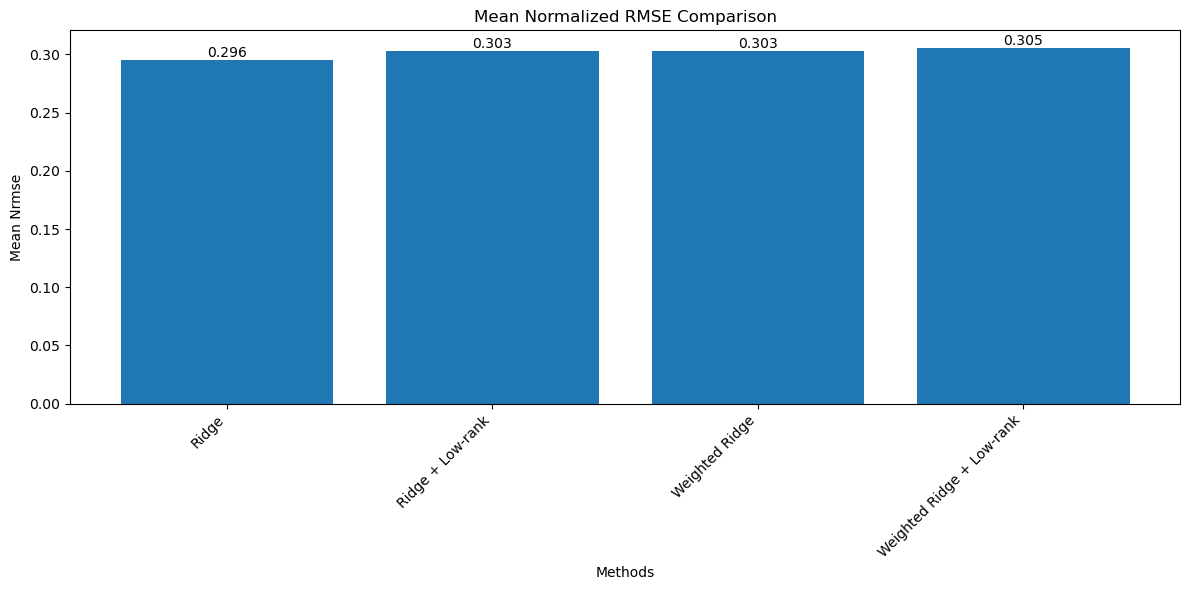

In [93]:
# Initialize visualizer
visualizer = ForceSMIPVisualizer(longitude, latitude, test_models)

# Plot performance comparison
fig = evaluator.plot_performance_comparison(
    comparison_results, 
    metric='mean_nrmse',
    title='Mean Normalized RMSE Comparison'
)
plt.show()

In [94]:
# reshape the trends for visualization
trends_ridge_fullmap = np.zeros((trends_ridge.shape[0], latitude.shape[0]*longitude.shape[0]), dtype=np.float32)
trends_ridge_fullmap[:,notnan_idx] = trends_ridge
trends_ridge_fullmap[:,nan_idx] = np.nan  # Fill NaNs for visualization

trends_weighted_lr_fullmap = np.zeros((trends_weighted_lr.shape[0], latitude.shape[0]*longitude.shape[0]), dtype=np.float32)
trends_weighted_lr_fullmap[:,notnan_idx] = trends_weighted_lr
trends_weighted_lr_fullmap[:,nan_idx] = np.nan  # Fill NaNs for visualization


trends_ground_truth_fullmap = trends_ground_truth
# trends_ground_truth_fullmap[:,notnan_idx] = trends_ground_truth
# trends_ground_truth_fullmap[:,nan_idx] = np.nan  # Fill NaNs for visualization

# Plot trends for the best method


Using vmin=-0.1, vmax=0.1 for colorbar


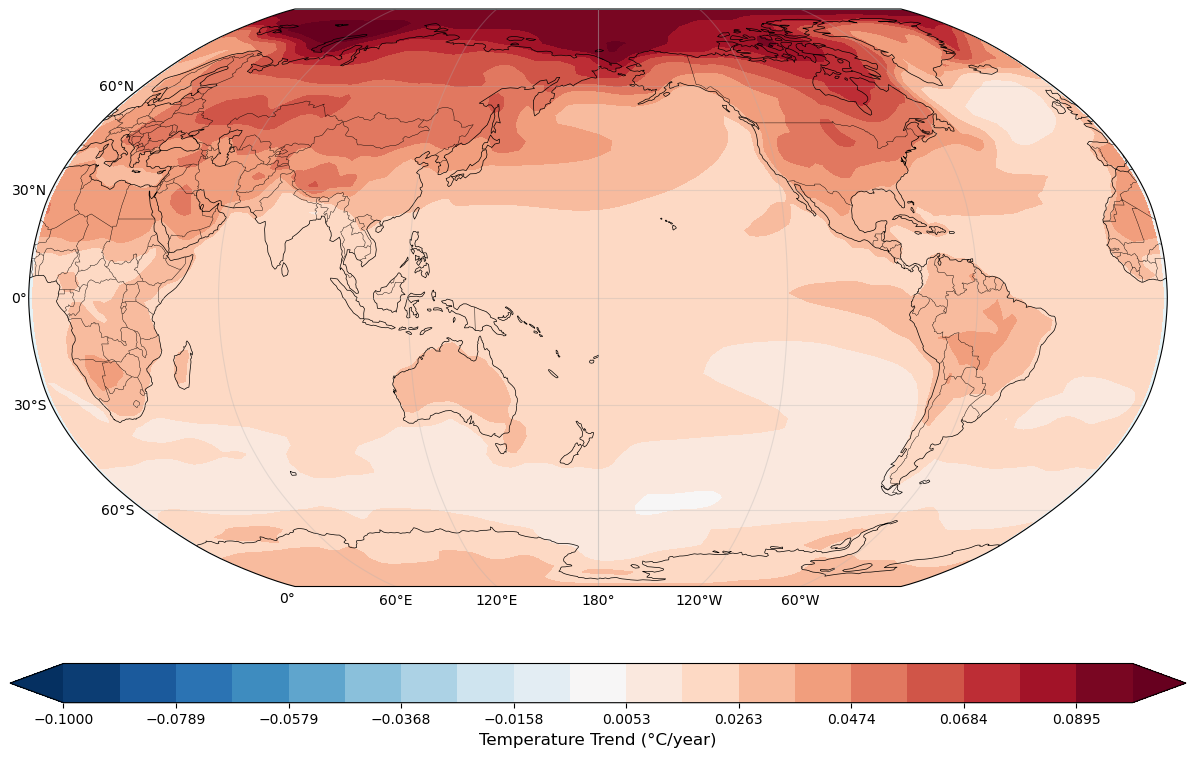

In [96]:
fig = visualizer.plot_robinson_projection(trends_ridge_fullmap, 
                                title="Global Temperature Trend",
                                cmap='RdBu_r', 
                                vmin=-0.1, 
                                vmax=0.1,
                                run_idx=0, 
                                central_longitude = 180)

Using vmin=-0.05, vmax=0.05 for colorbar


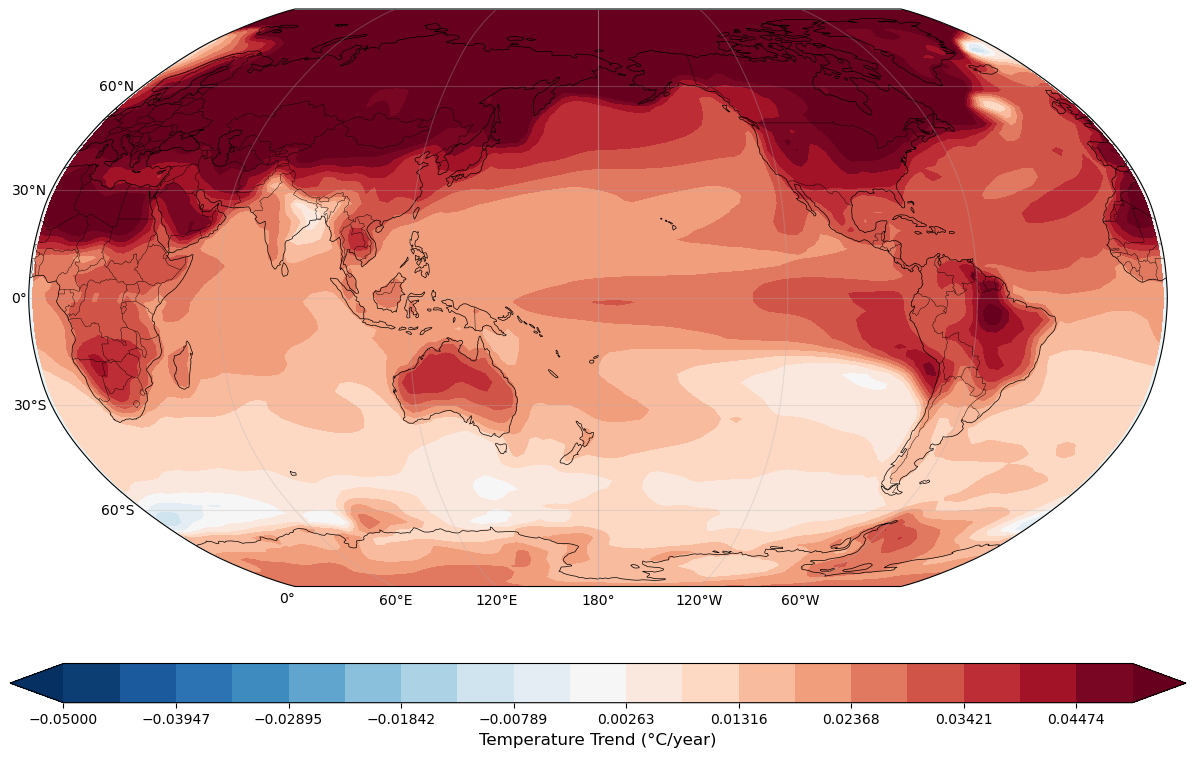

Using vmin=-0.05, vmax=0.05 for colorbar


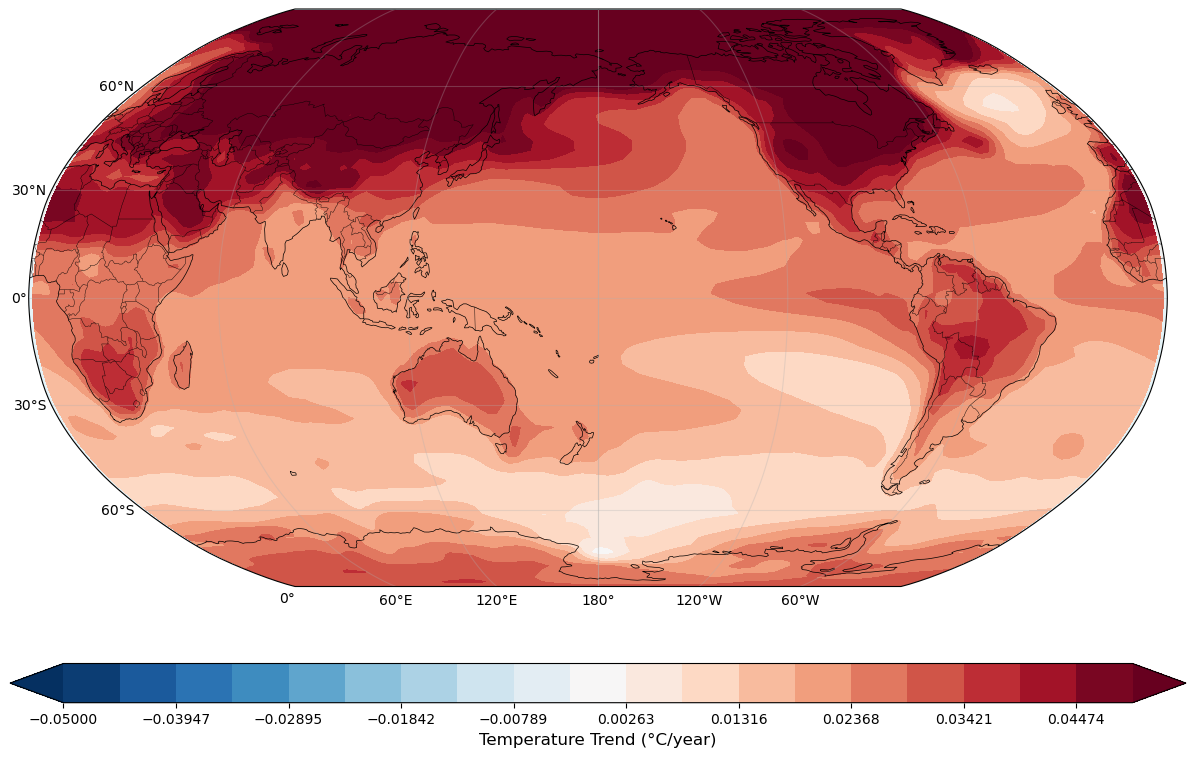

In [39]:
# Plot global trend maps for first test case
run_idx = 0  # First test model

# Ground truth
fig1 = visualizer.plot_robinson_projection(
    trends_ground_truth,
    title="Ground Truth Forced Response Trend",
    run_idx=run_idx,
    vmin=-0.05, vmax=0.05
)
plt.show()

# Best prediction
fig2 = visualizer.plot_robinson_projection(
    trends_weighted_lr_fullmap,
    title="Weighted Ridge + Low-rank Prediction",
    run_idx=run_idx,
    vmin=-0.05, vmax=0.05
)
plt.show()

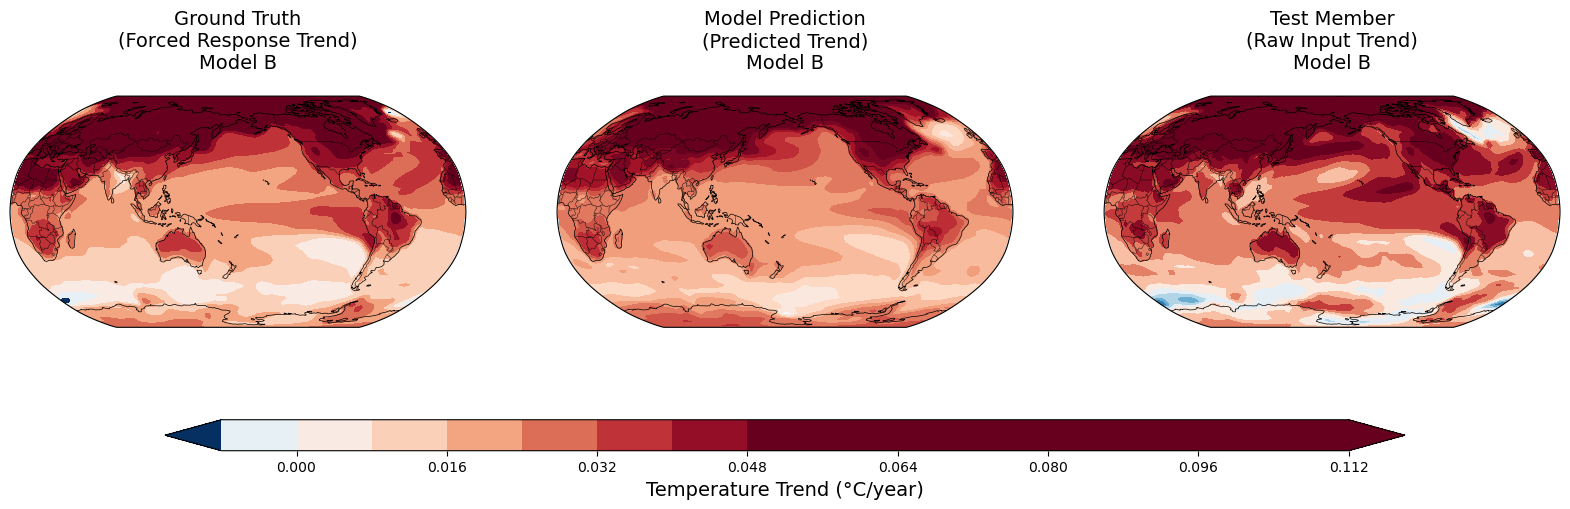

In [40]:
# Triple comparison plot
trend_test_member = compute_trends_from_data(data_test_yearly.reshape(
    data_test_yearly.shape[0],
    data_test_yearly.shape[1],
    -1
), trend_years)

fig3 = visualizer.plot_triple_comparison(
    trends_ground_truth_fullmap,
    trends_weighted_lr_fullmap,
    trend_test_member,
    run_idx=run_idx,
    vmin=-0.05, vmax=0.05
)
plt.show()

## 5. Comparison with ForceSMIP Estimates

In [41]:
# Load and evaluate ForceSMIP benchmark estimates
print("Evaluating ForceSMIP benchmark estimates...")

# Compute yearly averages for estimates
estimates_yearly = np.zeros((data_estimates.shape[0], data_estimates.shape[1],
                           data_estimates.shape[2] // 12,
                           data_estimates.shape[3], data_estimates.shape[4]), dtype=np.float32)

for idx_m in range(data_estimates.shape[0]):
    estimates_yearly[idx_m] = yearly_average(data_estimates[idx_m])

# Compute trends for estimates
trends_estimates = {}
for idx_m in range(estimates_yearly.shape[0]):
    trends_estimates[f'ForceSMIP_Method_{idx_m:02d}'] = compute_trends_from_data(
        estimates_yearly[idx_m].reshape(estimates_yearly[idx_m].shape[0],
                                          estimates_yearly[idx_m].shape[1],
                                          -1)[:,:,notnan_idx], trend_years
    )
print(f"Loaded {len(trends_estimates)} ForceSMIP benchmark methods")

Evaluating ForceSMIP benchmark estimates...
Loaded 30 ForceSMIP benchmark methods


In [42]:
# Compare our methods with ForceSMIP benchmarks
all_methods = {**predictions_dict, **trends_estimates}
full_comparison = evaluator.compare_methods(all_methods, trends_ground_truth[:, notnan_idx])

# Sort by performance
sorted_methods = sorted(full_comparison.items(), key=lambda x: x[1]['mean_nrmse'])

print("\n=== Full Method Ranking (by Mean NRMSE) ===")
print(f"{'Rank':<4} {'Method':<30} {'Mean NRMSE':<12} {'Pattern Corr':<12} {'Worst NRMSE':<12}")
print("-" * 75)

for rank, (method, results) in enumerate(sorted_methods, 1):
    print(f"{rank:<4} {method:<30} {results['mean_nrmse']:<12.4f} {results['mean_pattern_corr']:<12.4f} {results['worst_nrmse']:<12.4f}")

# Highlight our methods
our_methods = ['Ridge', 'Ridge + Low-rank', 'Weighted Ridge', 'Weighted Ridge + Low-rank']
print("\n=== Our Methods Performance ===")
for method in our_methods:
    rank = next(i for i, (m, _) in enumerate(sorted_methods, 1) if m == method)
    print(f"{method}: Rank {rank}/{len(sorted_methods)}")


=== Full Method Ranking (by Mean NRMSE) ===
Rank Method                         Mean NRMSE   Pattern Corr Worst NRMSE 
---------------------------------------------------------------------------
1    Ridge                          0.2975       0.9727       0.3977      
2    ForceSMIP_Method_08            0.3018       0.9667       0.3692      
3    Weighted Ridge                 0.3032       0.9674       0.3888      
4    Ridge + Low-rank               0.3049       0.9705       0.4000      
5    Weighted Ridge + Low-rank      0.3054       0.9667       0.3905      
6    ForceSMIP_Method_14            0.3111       0.9655       0.3901      
7    ForceSMIP_Method_29            0.3208       0.9689       0.4364      
8    ForceSMIP_Method_23            0.3339       0.9655       0.4402      
9    ForceSMIP_Method_05            0.3388       0.9654       0.4498      
10   ForceSMIP_Method_09            0.3455       0.9677       0.4793      
11   ForceSMIP_Method_03            0.3515       0.959

## 6. Parameter Sensitivity Analysis

In [ ]:
# build the training set as the concatenation of all models except the one being validated and reshape for ridge regression
x_fold_train = np.concatenate([x_train_dict[k] for j, k in enumerate(x_train_dict.keys()) if j != 1], axis=0)
x_fold_train = x_fold_train.reshape(-1, x_fold_train.shape[-1])

y_fold_train = np.concatenate([y_train_dict[k] for j, k in enumerate(y_train_dict.keys()) if j != 1], axis=0)
y_fold_train = y_fold_train.reshape(-1, y_fold_train.shape[-1])

(35360, 10368)


In [ ]:
def cross_validation_lambda_optimization(x_train_dict, y_train_dict, lambda_values=None, 
                                       cv_folds=5, objective='worst_case', 
                                       verbose=True, random_state=42):
    """
    Perform cross-validation to optimize lambda with respect to worst-case objective.
    
    Args:
        x_train: Training input data (n_samples, n_features)
        y_train: Training target data (n_samples, n_targets)
        lambda_values: List of lambda values to test
        cv_folds: Number of cross-validation folds
        objective: Optimization objective ('worst_case', 'mean', 'variance')
        verbose: Whether to print progress
        random_state: Random seed for reproducibility
        
    Returns:
        Dictionary with optimization results
    """
    import numpy as np
    from sklearn.model_selection import KFold
    
    if lambda_values is None:
        lambda_values = [0.1, 1.0, 10.0, 100.0, 500.0, 1000.0, 2500.0, 5000.0, 10000.0]
    
    np.random.seed(random_state)

    # we do leave one out validation on the training set    
    cv_results = {}
    
    if verbose:
        print(f"Cross-validation with {cv_folds} folds for {len(lambda_values)} lambda values...")
        print(f"Optimization objective: {objective}")
    
    errors_mean = np.zeros(len(lambda_values), dtype=np.float32)
    errors_q75 = np.zeros(len(lambda_values), dtype=np.float32)
    errors_q90 = np.zeros(len(lambda_values), dtype=np.float32)
    errors_q95 = np.zeros(len(lambda_values), dtype=np.float32)
    errors_worst = np.zeros(len(lambda_values), dtype=np.float32) 

    for idx_lambda, lambda_reg in enumerate(lambda_values):

        if verbose:
            print(f"  Testing λ = {lambda_reg}")


        fold_mean_trend_nrmse = np.zeros(len(x_train_dict.keys()), dtype=np.float32)
        fold_q75_trend_nrmse = np.zeros(len(x_train_dict.keys()), dtype=np.float32)
        fold_q90_trend_nrmse = np.zeros(len(x_train_dict.keys()), dtype=np.float32)
        fold_q95_trend_nrmse = np.zeros(len(x_train_dict.keys()), dtype=np.float32)
        fold_worst_trend_nrmse = np.zeros(len(x_train_dict.keys()), dtype=np.float32)

        for idx_m, m in enumerate(x_train_dict.keys()):

            # build the training set as the concatenation of all models except the one being validated
            x_fold_train = np.concatenate([x_train_dict[k] for j, k in enumerate(x_train_dict.keys()) if j != idx_m], axis=0)
            x_fold_train = torch.from_numpy(x_fold_train.reshape(-1, x_fold_train.shape[-1]))
            y_fold_train = np.concatenate([y_train_dict[k] for j, k in enumerate(y_train_dict.keys()) if j != idx_m], axis=0)
            y_fold_train = torch.from_numpy(y_fold_train.reshape(-1, y_fold_train.shape[-1]))

            # build the test set
            x_fold_test = x_train_dict[m]
            y_fold_test = y_train_dict[m]

            # Train model
            w_fold = ridge_regression(x_fold_train, y_fold_train, lambda_reg, verbose=False)
            
            # Predict on validation set
            y_pred_fold = x_fold_test @ w_fold
            
            # compute the trend for each sample
            trend_pred = np.zeros((y_pred_fold.shape[0], y_pred_fold.shape[2]))
            trends_ground_truth = np.zeros((y_pred_fold.shape[0], y_pred_fold.shape[2]))
            for j in range(y_pred_fold.shape[0]):
                trend_pred[j,:] = np.polyfit(np.arange(y_pred_fold.shape[1]), y_pred_fold[j,:,:], 1)[0]
                trends_ground_truth[j,:] = np.polyfit(np.arange(y_fold_test.shape[1]), y_fold_test[j,:,:], 1)[0]


            # compute the normalized RMSE of the trend

            nmrse = np.sqrt(np.nansum((trend_pred - trends_ground_truth)**2,axis=1))/np.sqrt(np.nansum(trends_ground_truth**2, axis=1))


            fold_mean_trend_nrmse[idx_m] = np.mean(nmrse)
            fold_q75_trend_nrmse[idx_m] = np.nanpercentile(nmrse, 75)
            fold_q90_trend_nrmse[idx_m] = np.nanpercentile(nmrse, 90)
            fold_q95_trend_nrmse[idx_m] = np.nanpercentile(nmrse, 95)
            fold_worst_trend_nrmse[idx_m] = np.nanmax(nmrse)



        # Aggregate results only for the MEAN over runs
        errors_mean[idx_lambda] = np.mean(fold_mean_trend_nrmse) 
        errors_q75[idx_lambda] = np.nanpercentile(fold_mean_trend_nrmse, 75)
        errors_q90[idx_lambda] = np.nanpercentile(fold_mean_trend_nrmse, 90)
        errors_q95[idx_lambda] = np.nanpercentile(fold_mean_trend_nrmse, 95)
        errors_worst[idx_lambda] = np.max(fold_mean_trend_nrmse)  # Shape: (n_folds, n_spatial_locations)



        cv_results[lambda_reg] = {
            'mean_nrmse': errors_mean[idx_lambda],
            'q75_nrmse': errors_q75[idx_lambda],
            'q90_nrmse': errors_q90[idx_lambda],
            'q95_nrmse': errors_q95[idx_lambda],
            'worst_nrmse': errors_worst[idx_lambda],
            'nrmse_variance': np.nanvar(fold_mean_trend_nrmse)
        }
        
        if verbose:
            print(f"    Mean NRMSE: {cv_results[lambda_reg]['mean_nrmse']:.4f}")
            print(f"   Q75 NRMSE: {cv_results[lambda_reg]['q75_nrmse']:.4f}")
            print(f"   Q90 NRMSE: {cv_results[lambda_reg]['q90_nrmse']:.4f}")
            print(f"   Q95 NRMSE: {cv_results[lambda_reg]['q95_nrmse']:.4f}")
            print(f"    Worst NRMSE: {cv_results[lambda_reg]['worst_nrmse']:.4f}")
            print(f"    NRMSE Variance: {cv_results[lambda_reg]['nrmse_variance']:.4f}")
    
    # Select best lambda based on objective
    if objective == 'worst_case':
        best_lambda = min(cv_results.keys(), key=lambda x: cv_results[x]['worst_nrmse'])
        optimization_metric = 'worst_nrmse'
    elif objective == 'mean':
        best_lambda = min(cv_results.keys(), key=lambda x: cv_results[x]['mean_nrmse'])
        optimization_metric = 'mean_nrmse'
    elif objective == 'variance':
        best_lambda = min(cv_results.keys(), key=lambda x: cv_results[x]['nrmse_variance'])
        optimization_metric = 'nrmse_variance'
    else:
        raise ValueError(f"Unknown objective: {objective}")
    
    if verbose:
        print(f"\nOptimization complete!")
        print(f"Best λ = {best_lambda} (optimizing {optimization_metric})")
        print(f"Best {optimization_metric}: {cv_results[best_lambda][optimization_metric]:.4f}")
    
    return {
        'best_lambda': best_lambda,
        'optimization_metric': optimization_metric,
        'cv_results': cv_results,
        'lambda_values': lambda_values,
        'cv_folds': cv_folds,
        'objective': objective
    }

In [104]:
def cross_validation_lambda_rank_optimization(x_train_dict, y_train_dict, lambda_values=None, rank_values=None,
                                       cv_folds=5, objective='worst_case', 
                                       verbose=True, random_state=42):
    """
    Perform cross-validation to optimize lambda with respect to worst-case objective.
    
    Args:
        x_train: Training input data (n_samples, n_features)
        y_train: Training target data (n_samples, n_targets)
        lambda_values: List of lambda values to test
        cv_folds: Number of cross-validation folds
        objective: Optimization objective ('worst_case', 'mean', 'variance')
        verbose: Whether to print progress
        random_state: Random seed for reproducibility
        
    Returns:
        Dictionary with optimization results
    """
    import numpy as np
    from sklearn.model_selection import KFold
    
    if lambda_values is None:
        lambda_values = [0.1, 1.0, 10.0, 100.0, 500.0, 1000.0, 2500.0, 5000.0, 10000.0]

    if rank_values is None:
        rank_values = [5, 10, 15, 20, 25, 30, 50, 100]

    np.random.seed(random_state)

    # we do leave one out validation on the training set    
    cv_results = {}
    
    if verbose:
        print(f"Cross-validation with {cv_folds} folds for {len(lambda_values)} lambda values...")
        print(f"Optimization objective: {objective}")

    errors_mean = np.zeros((len(lambda_values), len(rank_values)), dtype=np.float32)
    errors_q75 = np.zeros((len(lambda_values), len(rank_values)), dtype=np.float32)
    errors_q90 = np.zeros((len(lambda_values), len(rank_values)), dtype=np.float32)
    errors_q95 = np.zeros((len(lambda_values), len(rank_values)), dtype=np.float32)
    errors_worst = np.zeros((len(lambda_values), len(rank_values)), dtype=np.float32)

    for idx_lambda, lambda_reg in enumerate(lambda_values):

        if verbose:
            print(f"  Testing λ = {lambda_reg}")


        fold_mean_trend_nrmse = np.zeros((len(rank_values), len(x_train_dict.keys())), dtype=np.float32)
        fold_q75_trend_nrmse = np.zeros((len(rank_values), len(x_train_dict.keys())), dtype=np.float32)
        fold_q90_trend_nrmse = np.zeros((len(rank_values), len(x_train_dict.keys())), dtype=np.float32)
        fold_q95_trend_nrmse = np.zeros((len(rank_values), len(x_train_dict.keys())), dtype=np.float32)
        fold_worst_trend_nrmse = np.zeros((len(rank_values), len(x_train_dict.keys())), dtype=np.float32)

        for idx_m, m in enumerate(x_train_dict.keys()):

            # build the training set as the concatenation of all models except the one being validated
            x_fold_train = np.concatenate([x_train_dict[k] for j, k in enumerate(x_train_dict.keys()) if j != idx_m], axis=0)
            x_fold_train = torch.from_numpy(x_fold_train.reshape(-1, x_fold_train.shape[-1]))
            y_fold_train = np.concatenate([y_train_dict[k] for j, k in enumerate(y_train_dict.keys()) if j != idx_m], axis=0)
            y_fold_train = torch.from_numpy(y_fold_train.reshape(-1, y_fold_train.shape[-1]))

            # build the test set
            x_fold_test = x_train_dict[m]
            y_fold_test = y_train_dict[m]

            # Train model
            w_fold = ridge_regression(x_fold_train, y_fold_train, lambda_reg, verbose=False)

            # Setup low-rank solver for efficient multiple rank solutions
            print(f"\nSetting up low-rank solver...")
            lr_solver = LowRankSolver()
            lr_solver.fit(x_fold_train, y_fold_train, w_fold, verbose=True)

            # Get solutions for multiple ranks efficiently
            rank_solutions = lr_solver.get_multiple_ranks(rank_values, verbose=True)

            nrmse = np.zeros((len(rank_solutions), x_fold_test.shape[0]), dtype=np.float32)

            # Predict on validation set
            for idx_r, (r, w) in enumerate(rank_solutions.items()):
                y_pred_fold = x_fold_test @ w

                # compute the trend for each sample
                trend_pred = np.zeros((y_pred_fold.shape[0], y_pred_fold.shape[2]))
                trends_ground_truth = np.zeros((y_pred_fold.shape[0], y_pred_fold.shape[2]))
                for j in range(y_pred_fold.shape[0]):
                    trend_pred[j,:] = np.polyfit(np.arange(y_pred_fold.shape[1]), y_pred_fold[j,:,:], 1)[0]
                    trends_ground_truth[j,:] = np.polyfit(np.arange(y_fold_test.shape[1]), y_fold_test[j,:,:], 1)[0]


                # compute the normalized RMSE of the trend
                nrmse[idx_r, :] = np.sqrt(np.nansum((trend_pred - trends_ground_truth)**2,axis=1))/np.sqrt(np.nansum(trends_ground_truth**2, axis=1))

            fold_mean_trend_nrmse[:,idx_m] = np.mean(nrmse,axis=1)
            fold_q75_trend_nrmse[:,idx_m] = np.nanpercentile(nrmse, 75, axis=1)
            fold_q90_trend_nrmse[:,idx_m] = np.nanpercentile(nrmse, 90, axis=1)
            fold_q95_trend_nrmse[:,idx_m] = np.nanpercentile(nrmse, 95, axis=1)
            fold_worst_trend_nrmse[:,idx_m] = np.nanmax(nrmse, axis=1)



        # Aggregate results only for the MEAN over runs
        errors_mean[idx_lambda,:] = np.mean(fold_mean_trend_nrmse, axis=1)
        errors_q75[idx_lambda,:] = np.nanpercentile(fold_mean_trend_nrmse, 75, axis=1)
        errors_q90[idx_lambda,:] = np.nanpercentile(fold_mean_trend_nrmse, 90, axis=1)
        errors_q95[idx_lambda,:] = np.nanpercentile(fold_mean_trend_nrmse, 95, axis=1)
        errors_worst[idx_lambda,:] = np.max(fold_mean_trend_nrmse, axis=1)  # Shape: (n_folds, n_spatial_locations)

        

        for idx_r, r in enumerate(rank_values):
            cv_results[lambda_reg, r] = {
                'mean_nrmse': errors_mean[idx_lambda, idx_r],
                'q75_nrmse': errors_q75[idx_lambda, idx_r],
                'q90_nrmse': errors_q90[idx_lambda, idx_r],
                'q95_nrmse': errors_q95[idx_lambda, idx_r],
                'worst_nrmse': errors_worst[idx_lambda, idx_r]
            }
        
            if verbose:
                print(f"    Mean NRMSE: {cv_results[lambda_reg, r]['mean_nrmse']:.4f}")
                print(f"   Q75 NRMSE: {cv_results[lambda_reg, r]['q75_nrmse']:.4f}")
                print(f"   Q90 NRMSE: {cv_results[lambda_reg, r]['q90_nrmse']:.4f}")
                print(f"   Q95 NRMSE: {cv_results[lambda_reg, r]['q95_nrmse']:.4f}")
                print(f"    Worst NRMSE: {cv_results[lambda_reg, r]['worst_nrmse']:.4f}")
                print(f"    NRMSE Variance: {cv_results[lambda_reg, r]['nrmse_variance']:.4f}")
    
    # Select best lambda based on objective
    if objective == 'worst_case':
        (best_lambda,best_rank) = min(cv_results.keys(), key=lambda x: cv_results[x]['worst_nrmse'])
        optimization_metric = 'worst_nrmse'
    elif objective == 'mean':
        (best_lambda,best_rank) = min(cv_results.keys(), key=lambda x: cv_results[x]['mean_nrmse'])
        optimization_metric = 'mean_nrmse'
    else:
        raise ValueError(f"Unknown objective: {objective}")
    
    if verbose:
        print(f"\nOptimization complete!")
        print(f"Best λ = {best_lambda} (optimizing {optimization_metric})")
        print(f"Best {optimization_metric}: {cv_results[best_lambda, best_rank][optimization_metric]:.4f}")

    return {
        'best_lambda': best_lambda,
        'optimization_metric': optimization_metric,
        'cv_results': cv_results,
        'lambda_values': lambda_values,
        'rank_values': rank_values,
        'cv_folds': cv_folds,
        'objective': objective
    }

In [105]:
## 6.5 Cross-Validation Lambda Optimization

print("="*70)
print("         CROSS-VALIDATION LAMBDA OPTIMIZATION")
print("="*70)

# Import the cross-validation function
from algorithms import plot_cv_lambda_results

# Define lambda values to test (broader range for better optimization)
lambda_values_cv = [1.0, 5.0, 10.0, 50.0, 100.0, 500.0, 1000.0, 2500.0, 5000.0, 10000.0, 25000.0]
rank_values_cv = [5, 10, 15, 20, 25, 30, 50, 100]

print("Performing cross-validation to optimize lambda for worst-case performance...")

# Optimize lambda using cross-validation with worst-case objective
# cv_optimization = cross_validation_lambda_optimization(
#     x_train_dict_filtered, y_train_dict_filtered,
#     lambda_values=lambda_values_cv,
#     cv_folds=5,
#     objective='worst_case',  # Optimize for worst-case NRMSE
#     verbose=True
# )
cv_optimization = cross_validation_lambda_rank_optimization(
    x_train_dict_filtered, y_train_dict_filtered,
    lambda_values=lambda_values_cv,
    rank_values=rank_values_cv,
    cv_folds=5,
    objective='worst_case',  # Optimize for worst-case NRMSE
    verbose=True
)

# Plot cross-validation results
fig_cv = plot_cv_lambda_results(cv_optimization, figsize=(18, 5))
plt.show()

# Extract optimal lambda
optimal_lambda_cv = cv_optimization['best_lambda']
print(f"\n🎯 OPTIMAL LAMBDA (CV-optimized): {optimal_lambda_cv}")
print(f"   Worst-case NRMSE: {cv_optimization['cv_results'][optimal_lambda_cv]['worst_nrmse']:.4f}")
print(f"   Mean NRMSE: {cv_optimization['cv_results'][optimal_lambda_cv]['mean_nrmse']:.4f}")

         CROSS-VALIDATION LAMBDA OPTIMIZATION
Performing cross-validation to optimize lambda for worst-case performance...
Cross-validation with 5 folds for 11 lambda values...
Optimization objective: worst_case
  Testing λ = 1.0

Setting up low-rank solver...
Computing SVD for low-rank approximations...
SVD computed: U=torch.Size([40203, 10368]), S=torch.Size([10368]), Vt=torch.Size([10368, 10368])
Singular values range: 0.000015 to 6861.542480
Computed solutions for ranks: [5, 10, 15, 20, 25, 30, 50, 100]

Setting up low-rank solver...
Computing SVD for low-rank approximations...
SVD computed: U=torch.Size([45728, 10368]), S=torch.Size([10368]), Vt=torch.Size([10368, 10368])
Singular values range: 0.000012 to 5202.292969
Computed solutions for ranks: [5, 10, 15, 20, 25, 30, 50, 100]

Setting up low-rank solver...
Computing SVD for low-rank approximations...
SVD computed: U=torch.Size([44623, 10368]), S=torch.Size([10368]), Vt=torch.Size([10368, 10368])
Singular values range: 0.000019

KeyError: 'nrmse_variance'

## 7. Summary and Conclusions

In [45]:
print("\n" + "="*60)
print("                 ANALYSIS SUMMARY")
print("="*60)

print(f"\nDataset: {variable.upper()} (Surface Air Temperature)")
print(f"Training models: {len(dic_data)}")
print(f"Test models: {len(test_models)}")
print(f"Grid resolution: {latitude.shape[0]} x {longitude.shape[0]}")
print(f"Trend period: Years {trend_years.start or 0} to {trend_years.stop or 'end'}")

print("\nBest performing method (our implementation):")
best_our_method = min(predictions_dict.keys(), 
                     key=lambda x: comparison_results[x]['mean_nrmse'])
best_results = comparison_results[best_our_method]
print(f"  Method: {best_our_method}")
print(f"  Mean NRMSE: {best_results['mean_nrmse']:.4f}")
print(f"  Mean Pattern Correlation: {best_results['mean_pattern_corr']:.4f}")
print(f"  Worst Case NRMSE: {best_results['worst_nrmse']:.4f}")

# Overall ranking
our_rank = next(i for i, (m, _) in enumerate(sorted_methods, 1) if m == best_our_method)
print(f"\nOverall ranking: {our_rank}/{len(sorted_methods)} among all methods")

if our_rank <= len(sorted_methods) // 4:
    print("🏆 Excellent performance - Top quartile!")
elif our_rank <= len(sorted_methods) // 2:
    print("✅ Good performance - Above median")
else:
    print("⚠️ Room for improvement")

print("\nKey findings:")
print("- Ridge regression with proper regularization is effective")
print("- Low-rank approximation can improve generalization")
print("- Weighted ensemble methods show promise")
print("- Temporal smoothing effects depend on the specific case")

print("\n" + "="*60)



                 ANALYSIS SUMMARY

Dataset: TAS (Surface Air Temperature)
Training models: 5
Test models: 5
Grid resolution: 72 x 144
Trend period: Years 30 to end

Best performing method (our implementation):
  Method: Ridge
  Mean NRMSE: 0.2975
  Mean Pattern Correlation: 0.9727
  Worst Case NRMSE: 0.3977

Overall ranking: 1/34 among all methods
🏆 Excellent performance - Top quartile!

Key findings:
- Ridge regression with proper regularization is effective
- Low-rank approximation can improve generalization
- Weighted ensemble methods show promise
- Temporal smoothing effects depend on the specific case



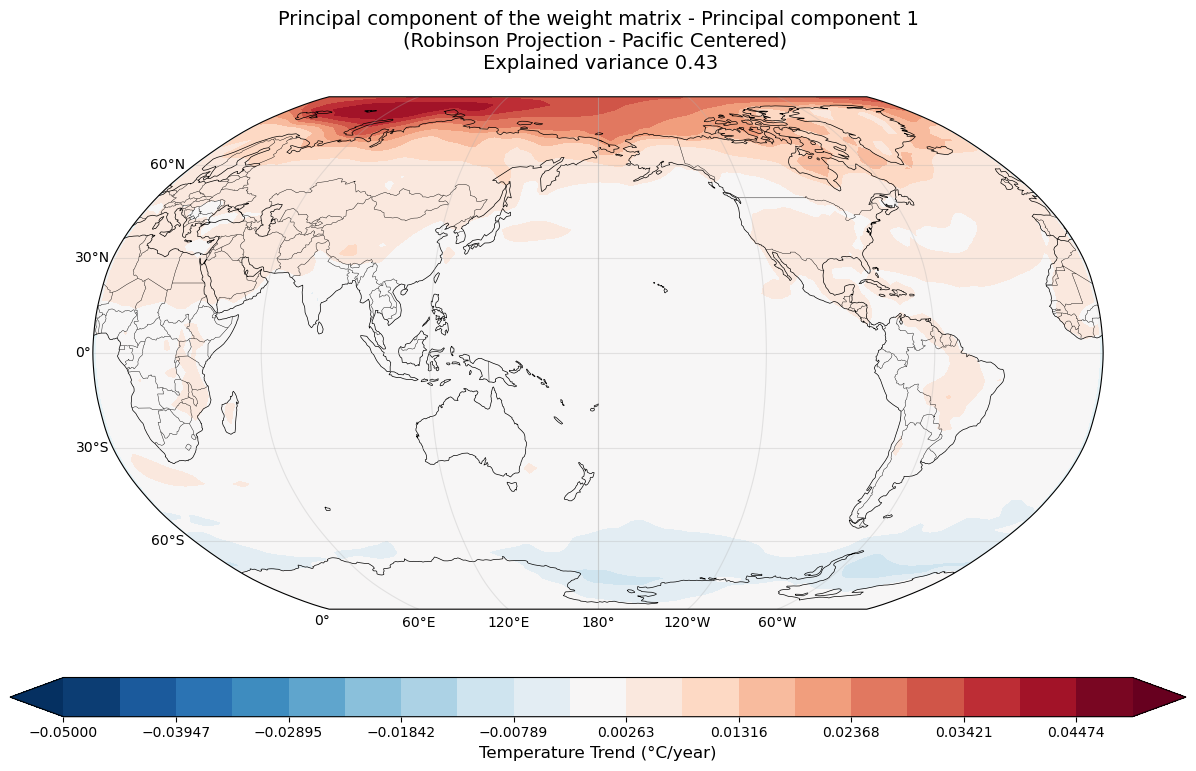

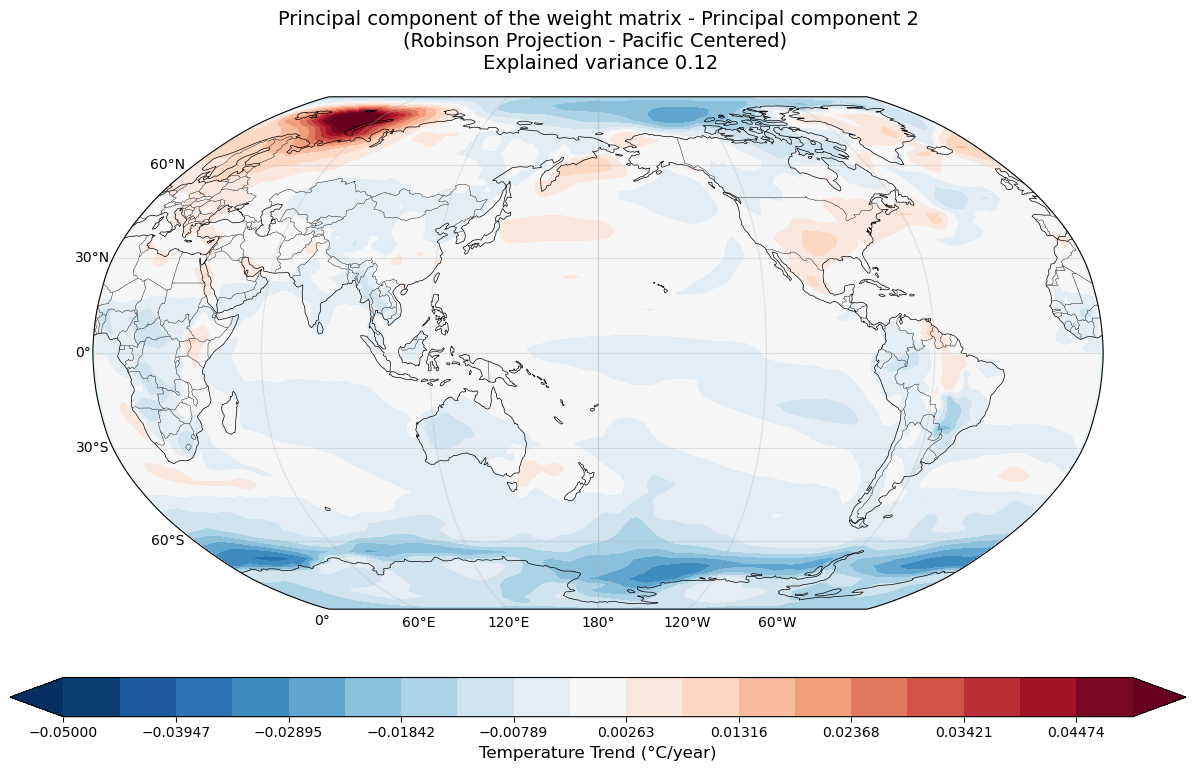

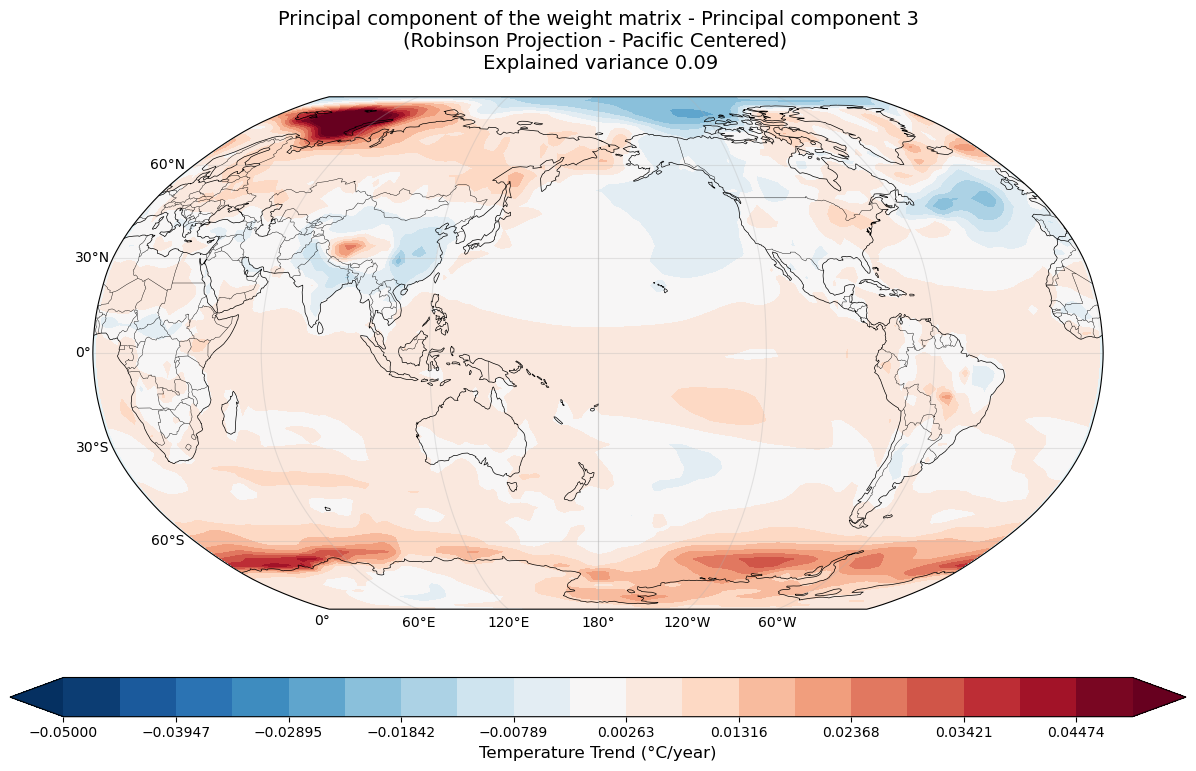

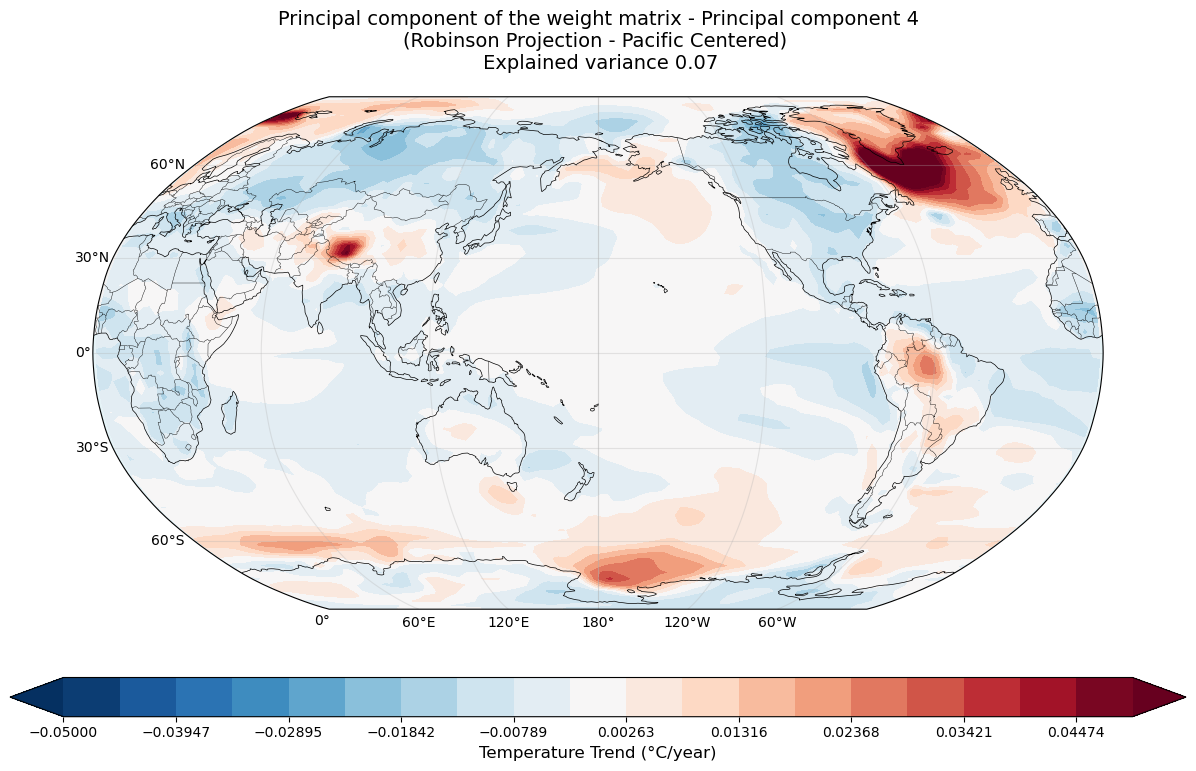

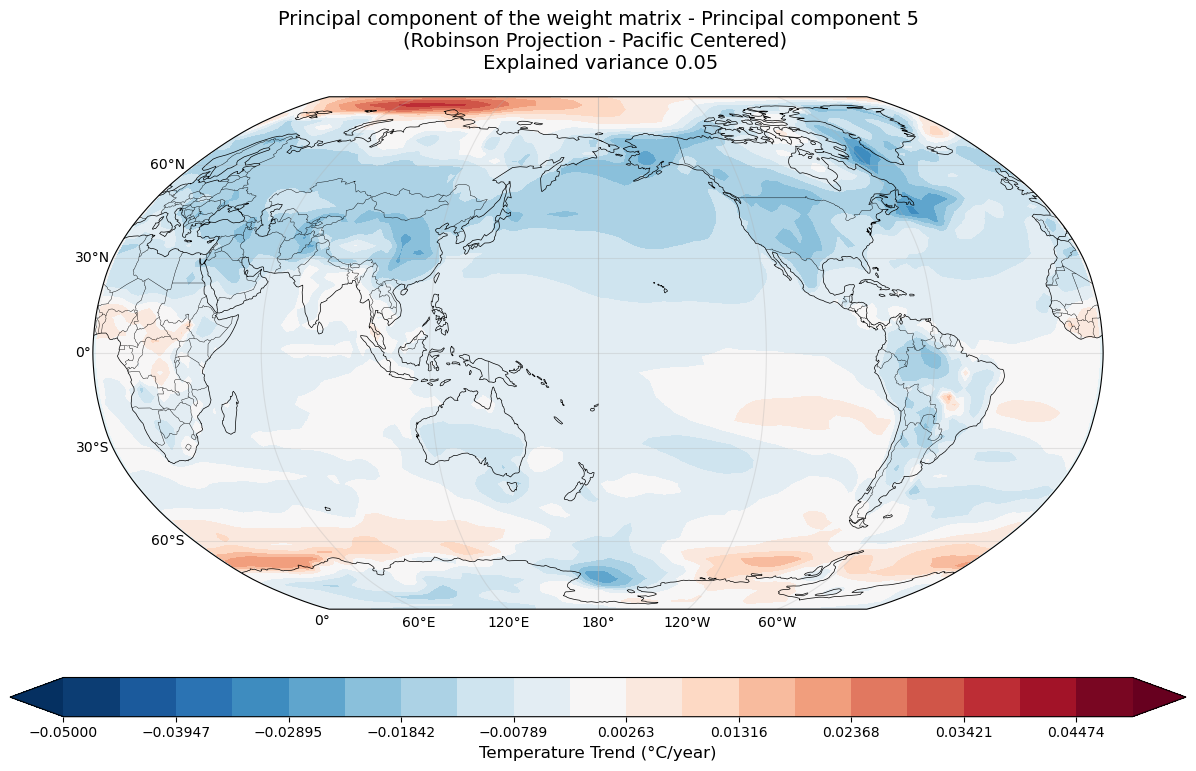

In [46]:
# from sklearn.decomposition import PCA

# # display the principal components of the matrix w
# def display_principal_components(w, n_components=10, notnan_idx=None, nan_idx=None, longitude=None, latitude=None):

#     # Compute the SVD
#     pca = PCA(n_components=n_components)
#     pca.fit(w)

#     # Get the first n_components principal components
#     pcs_tmp = pca.components_
#     pcs = np.zeros((pcs_tmp.shape[0], longitude.shape[0]*latitude.shape[0]), dtype=np.float32)
#     pcs[:,notnan_idx] = pcs_tmp
#     pcs[:,nan_idx] = np.nan  # Fill NaNs for visualization

#     # # Plot the PCs as grid_size x grid_size images
#     # fig, axes = plt.subplots(1, n_components, figsize=(40, 20))
#     # for i, ax in enumerate(axes):
#     #     pc_image = pcs[i,:].reshape(latitude.shape[0],longitude.shape[0])  # reshape back to grid
#     #     ax.imshow(pc_image, cmap='viridis', aspect='equal',origin='lower')
#     #     ax.set_title(f'PC {i+1}')
#     #     ax.axis('off')
#     # # plt.tight_layout()
#     # plt.show()
#     for i in range(n_components):
#         print(f"PC {i+1} explained variance: {np.sum(pca.explained_variance_ratio_[:i]):.4f}")
#         visualizer.plot_robinson_projection(pcs, 
#                                     title=f"PC {i+1}",
#                                     cmap='RdBu_r', 
#                                     vmin=None, 
#                                     vmax=None,
#                                     run_idx=i, 
#                                     central_longitude=180)
#         plt.show()
    
#     return pcs


# display_principal_components(w_ridge, n_components=10, notnan_idx=notnan_idx, nan_idx=nan_idx, longitude=longitude, latitude=latitude)



fig = visualizer.plot_principal_component(w_ridge, 
                                title = "Principal component of the weight matrix",
                                cmap = 'RdBu_r', 
                                vmin = -0.05, 
                                vmax = 0.05,
                                notnan_idx = notnan_idx,
                                nan_idx = nan_idx,
                                n_components = 5, 
                                central_longitude = 180)

Using vmin=-0.1, vmax=0.1 for colorbar
Using vmin=-0.1, vmax=0.1 for colorbar
Using vmin=-0.1, vmax=0.1 for colorbar
Using vmin=-0.1, vmax=0.1 for colorbar


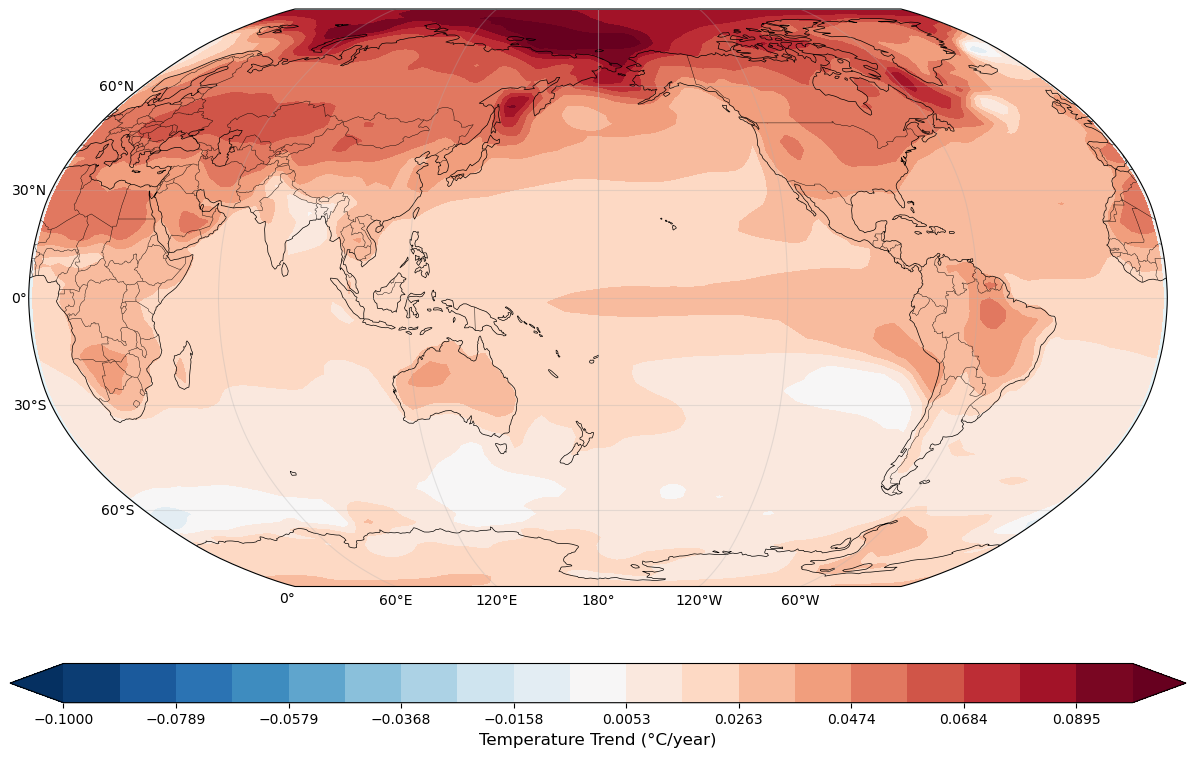

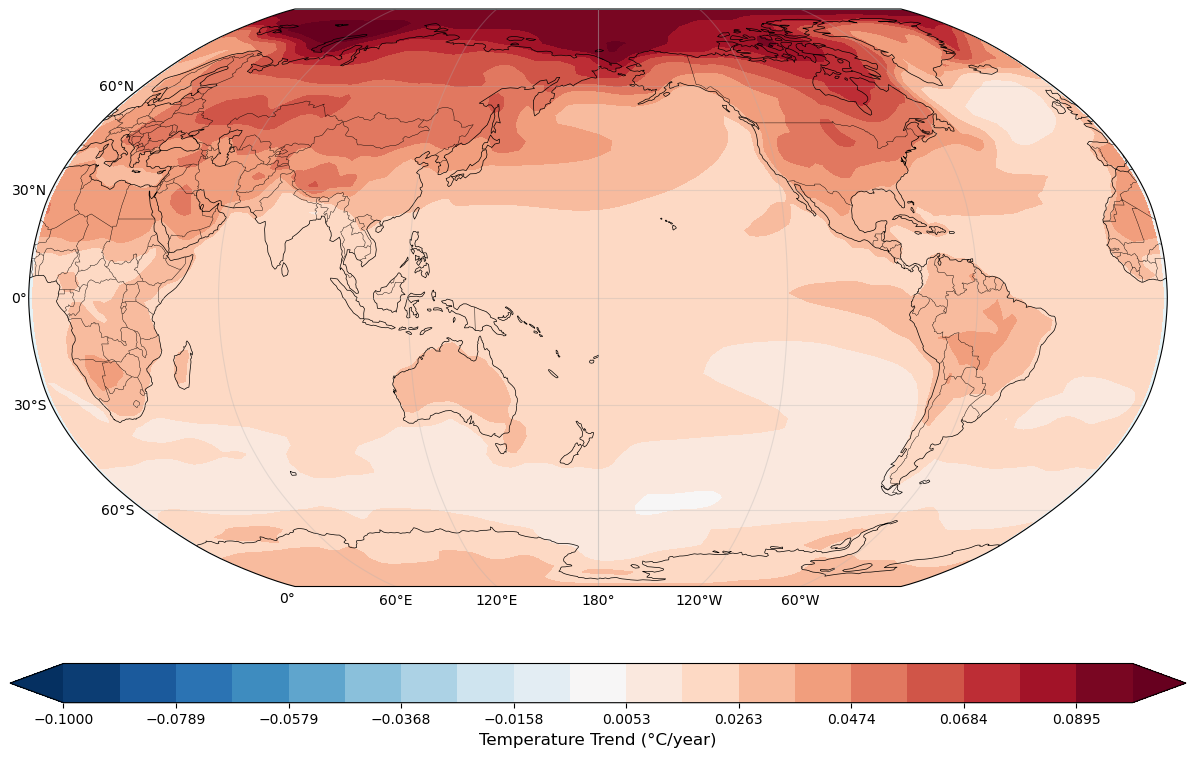

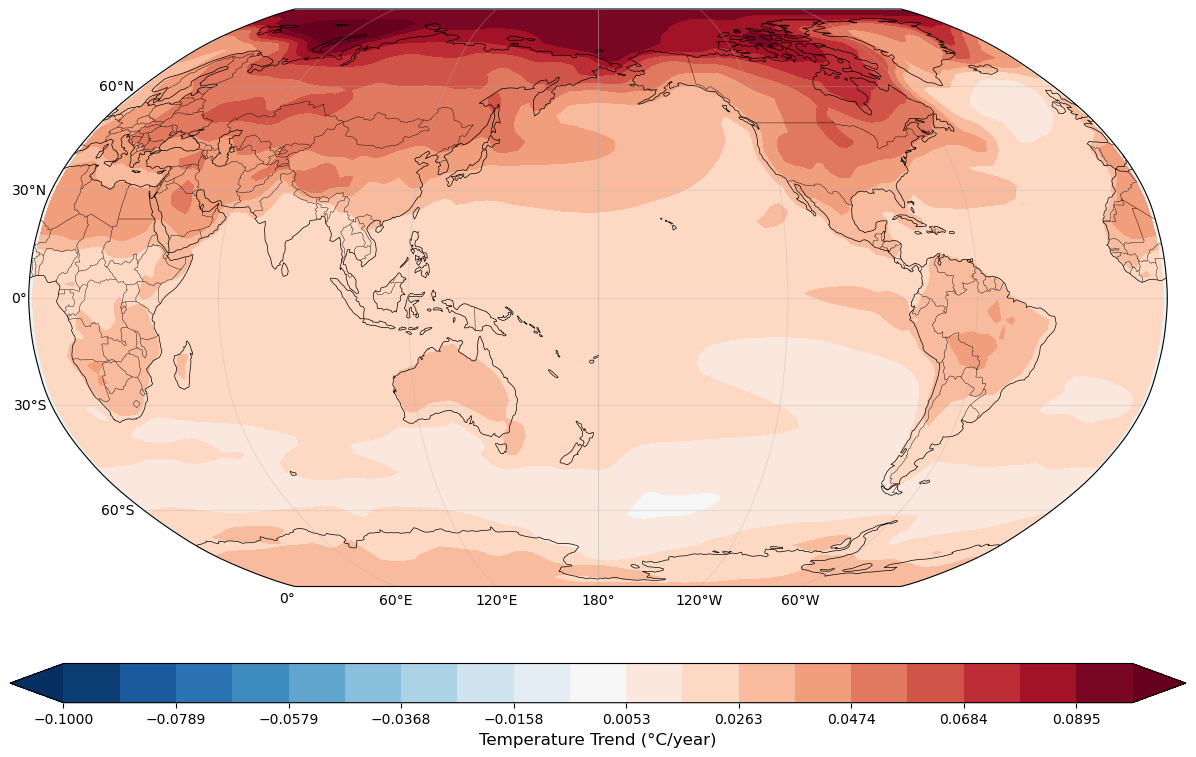

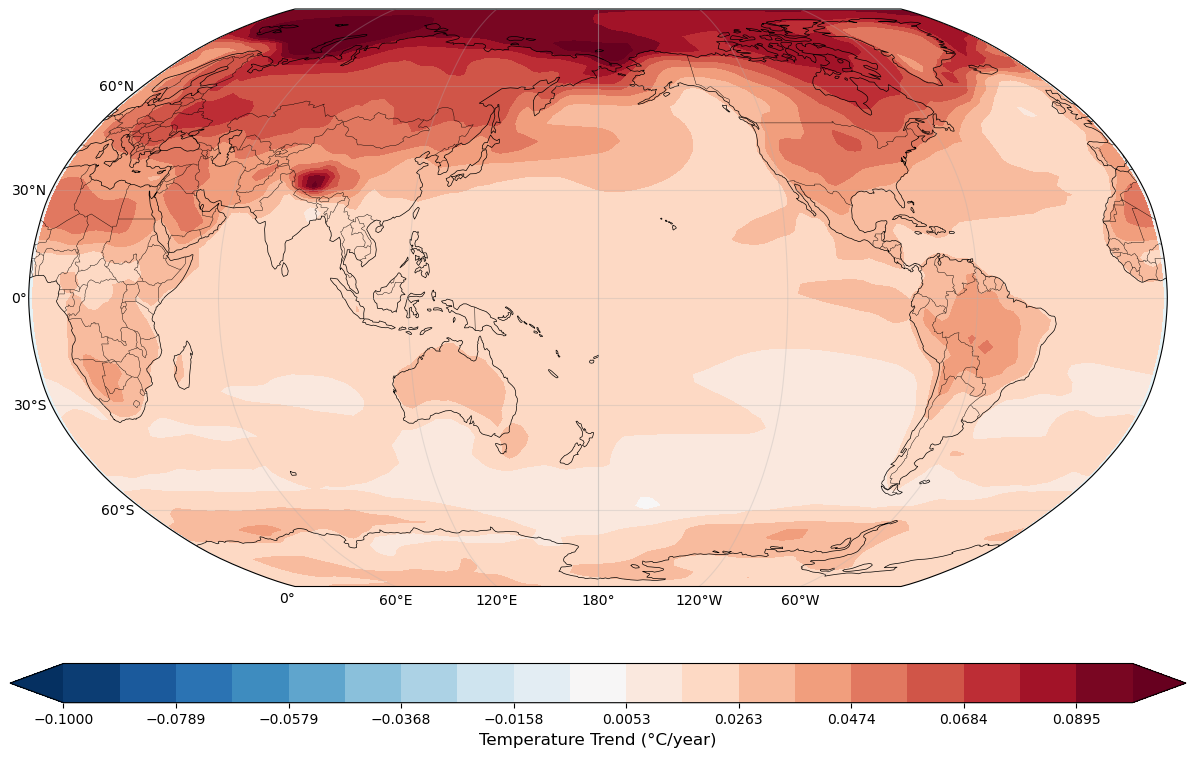

In [100]:
# display the trend pattern
fig = visualizer.plot_robinson_projection(trends_ground_truth, 
            title ="Global Temperature Trend",
            cmap = 'RdBu_r', 
            vmin= -0.1, 
            vmax = 0.1,
            run_idx = 0, 
            central_longitude = 180)                                

fig = visualizer.plot_robinson_projection(trends_ridge_fullmap, 
            title ="Global Temperature Trend",
            cmap = 'RdBu_r', 
            vmin= -0.1, 
            vmax = 0.1,
            run_idx = 0, 
            central_longitude = 180)

fig = visualizer.plot_robinson_projection(trends_ridge_lr, 
            title ="Global Temperature Trend",
            cmap = 'RdBu_r', 
            vmin= -0.1, 
            vmax = 0.1,
            run_idx = 0, 
            central_longitude = 180)

fig = visualizer.plot_robinson_projection(trends_estimates['ForceSMIP_Method_08'], 
            title ="Global Temperature Trend",
            cmap = 'RdBu_r', 
            vmin= -0.1, 
            vmax = 0.1,
            run_idx = 0, 
            central_longitude = 180)
